In [1]:
# Simulador de Drone Quadricóptero
# ================================
# Este notebook implementa um simulador completo com:
# - Dinâmica não-linear de um quadricóptero
# - Visualização 3D em tempo real
# - Controles: LQR (discreto), PID e SDRE (discreto)
# - Controle de atitude + altitude (Z) + velocidades XY

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.linalg import solve_discrete_are, inv, schur, solve
from scipy.integrate import odeint
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 100  # MB

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


# 1. Parâmetros do Drone

Definição dos parâmetros físicos do quadricóptero.

In [2]:
class DroneParams:
    """
    Parâmetros físicos do drone quadricóptero
    
    Baseado em ESP32 Drone (micro quadricóptero)
    Referência: Típico micro drone com frame 65-85mm
    - Massa total: ~50-100g (incluindo bateria LiPo 1S)
    - Motores: 7x16mm ou 8.5x20mm brushed/brushless
    - Hélices: 55mm ou 65mm
    """
    def __init__(self):
        # ===== Massa e gravidade =====
        self.m = 0.068       # massa total (kg) - ~68g típico para ESP32 drone
        self.g = 9.81        # gravidade (m/s²)
        
        # ===== Momentos de inércia (kg·m²) =====
        # Calculados para um frame quadrado de ~65mm
        # I = m * r² (aproximação para corpo rígido simétrico)
        # Para micro drones, os valores são muito pequenos
        self.Ixx = 6.5e-5    # momento de inércia em x (roll)
        self.Iyy = 6.5e-5    # momento de inércia em y (pitch)
        self.Izz = 1.2e-4    # momento de inércia em z (yaw) - maior devido à distribuição dos motores
        
        # ===== Geometria =====
        self.L = 0.0325      # distância do centro ao motor (m) - frame 65mm diagonal = 46mm, L = 32.5mm
        self.frame_size = 0.065  # tamanho do frame (m)
        
        # ===== Coeficientes dos motores =====
        # Para motores brushed 7x16mm ou 8520 típicos de micro drones
        self.kf = 1.5e-7     # coeficiente de empuxo (N/(rad/s)²)
        self.km = 2.5e-9     # coeficiente de torque (N·m/(rad/s)²)
        
        # Constante de empuxo/torque alternativa (mais intuitiva)
        self.ct = 1.0e-5     # thrust coefficient
        self.cq = 1.0e-7     # torque coefficient
        
        # ===== Limites dos motores =====
        # Motores brushed típicos: 30000-50000 RPM
        self.omega_min = 0           # velocidade mínima do motor (rad/s)
        self.omega_max = 4500        # velocidade máxima ~43000 RPM = 4500 rad/s
        
        # Empuxo máximo por motor (N) - tipicamente 15-25g por motor
        self.thrust_max_per_motor = 0.022 * self.g  # ~22g = 0.216N por motor
        self.thrust_total_max = 4 * self.thrust_max_per_motor  # ~0.86N total
        
        # ===== Coeficientes de arrasto aerodinâmico =====
        # Micro drones têm arrasto relativamente alto devido ao tamanho
        self.Ax = 0.010      # arrasto em x (N·s/m) - reduzido para escala do drone
        self.Ay = 0.010      # arrasto em y
        self.Az = 0.015      # arrasto em z (maior devido à área das hélices)
        
        # ===== Parâmetros da bateria =====
        self.battery_voltage = 3.7   # LiPo 1S (V)
        self.battery_capacity = 300  # mAh típico
        
        # ===== Limites de operação =====
        self.max_angle = np.deg2rad(45)  # ângulo máximo de inclinação (rad)
        self.max_angular_rate = np.deg2rad(300)  # taxa angular máxima (rad/s)
        
    def print_specs(self):
        """Imprime especificações do drone"""
        print("=" * 50)
        print("ESPECIFICAÇÕES DO ESP32 DRONE")
        print("=" * 50)
        print(f"Massa total: {self.m*1000:.1f}g")
        print(f"Tamanho do frame: {self.frame_size*1000:.0f}mm")
        print(f"Distância centro-motor: {self.L*1000:.1f}mm")
        print(f"Inércias: Ixx={self.Ixx:.2e}, Iyy={self.Iyy:.2e}, Izz={self.Izz:.2e} kg·m²")
        print(f"Empuxo máximo total: {self.thrust_total_max:.3f}N ({self.thrust_total_max/self.g*1000:.1f}g)")
        print(f"Relação empuxo/peso: {self.thrust_total_max/(self.m*self.g):.2f}")
        print(f"Bateria: {self.battery_voltage}V {self.battery_capacity}mAh")
        print("=" * 50)

# Instância global dos parâmetros
params = DroneParams()
params.print_specs()

ESPECIFICAÇÕES DO ESP32 DRONE
Massa total: 68.0g
Tamanho do frame: 65mm
Distância centro-motor: 32.5mm
Inércias: Ixx=6.50e-05, Iyy=6.50e-05, Izz=1.20e-04 kg·m²
Empuxo máximo total: 0.863N (88.0g)
Relação empuxo/peso: 1.29
Bateria: 3.7V 300mAh


# 2. Dinâmica Não-Linear do Quadricóptero

O modelo utiliza ângulos de Euler (roll, pitch, yaw) e considera as equações completas de Newton-Euler.

In [3]:
class QuadcopterDynamics:
    """
    Dinâmica não-linear completa do quadricóptero
    
    Estados (12):
        x = [x, y, z, vx, vy, vz, phi, theta, psi, p, q, r]
        
        Posição: x, y, z (inercial)
        Velocidade: vx, vy, vz (inercial)
        Ângulos de Euler: phi (roll), theta (pitch), psi (yaw)
        Velocidades angulares: p, q, r (corpo)
    
    Entradas (4):
        u = [U1, U2, U3, U4]
        U1 = empuxo total
        U2 = torque em roll
        U3 = torque em pitch
        U4 = torque em yaw
    """
    
    def __init__(self, params):
        self.params = params
        
    def rotation_matrix(self, phi, theta, psi):
        """Matriz de rotação do corpo para o inercial (Z-Y-X convention)"""
        cphi, sphi = np.cos(phi), np.sin(phi)
        cth, sth = np.cos(theta), np.sin(theta)
        cpsi, spsi = np.cos(psi), np.sin(psi)
        
        R = np.array([
            [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
            [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
            [-sth,     cth*sphi,                   cth*cphi]
        ])
        return R
    
    def euler_rate_matrix(self, phi, theta):
        """Matriz que relaciona velocidades angulares do corpo com derivadas de Euler"""
        cphi, sphi = np.cos(phi), np.sin(phi)
        cth, sth = np.cos(theta), np.sin(theta)
        
        # Evita singularidade em theta = ±90°
        if abs(cth) < 1e-6:
            cth = 1e-6 * np.sign(cth) if cth != 0 else 1e-6
            
        W = np.array([
            [1, sphi*sth/cth, cphi*sth/cth],
            [0, cphi,         -sphi],
            [0, sphi/cth,     cphi/cth]
        ])
        return W
    
    def dynamics(self, state, t, U):
        """
        Equações de movimento não-lineares
        
        Args:
            state: vetor de estados [x,y,z,vx,vy,vz,phi,theta,psi,p,q,r]
            t: tempo
            U: vetor de controle [U1, U2, U3, U4]
        
        Returns:
            state_dot: derivada do estado
        """
        p = self.params
        
        # Desempacota estados
        x, y, z = state[0:3]
        vx, vy, vz = state[3:6]
        phi, theta, psi = state[6:9]
        p_rate, q_rate, r_rate = state[9:12]
        
        # Entradas
        U1, U2, U3, U4 = U
        
        # Funções trigonométricas
        cphi, sphi = np.cos(phi), np.sin(phi)
        cth, sth = np.cos(theta), np.sin(theta)
        cpsi, spsi = np.cos(psi), np.sin(psi)
        
        # ===== Dinâmica translacional =====
        # Aceleração no referencial inercial
        ax = (U1/p.m) * (cpsi*sth*cphi + spsi*sphi) - (p.Ax/p.m)*vx
        ay = (U1/p.m) * (spsi*sth*cphi - cpsi*sphi) - (p.Ay/p.m)*vy
        az = (U1/p.m) * (cth*cphi) - p.g - (p.Az/p.m)*vz
        
        # ===== Dinâmica rotacional =====
        # Equações de Euler para corpo rígido
        p_dot = (U2 + (p.Iyy - p.Izz)*q_rate*r_rate) / p.Ixx
        q_dot = (U3 + (p.Izz - p.Ixx)*p_rate*r_rate) / p.Iyy
        r_dot = (U4 + (p.Ixx - p.Iyy)*p_rate*q_rate) / p.Izz
        
        # ===== Cinemática dos ângulos de Euler =====
        W = self.euler_rate_matrix(phi, theta)
        euler_rates = W @ np.array([p_rate, q_rate, r_rate])
        phi_dot, theta_dot, psi_dot = euler_rates
        
        # Monta o vetor de derivadas
        state_dot = np.array([
            vx, vy, vz,           # derivada da posição
            ax, ay, az,           # derivada da velocidade
            phi_dot, theta_dot, psi_dot,  # derivada dos ângulos
            p_dot, q_dot, r_dot   # derivada das taxas angulares
        ])
        
        return state_dot
    
    def step(self, state, U, dt):
        """Integração de um passo de tempo usando RK4"""
        k1 = self.dynamics(state, 0, U)
        k2 = self.dynamics(state + 0.5*dt*k1, 0, U)
        k3 = self.dynamics(state + 0.5*dt*k2, 0, U)
        k4 = self.dynamics(state + dt*k3, 0, U)
        
        new_state = state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        return new_state

# Instância da dinâmica
drone_dynamics = QuadcopterDynamics(params)
print("Dinâmica não-linear do quadricóptero inicializada!")

Dinâmica não-linear do quadricóptero inicializada!


# 3. Controladores

## 3.1 Controle PID para Altitude (Z) e Velocidades (XY)

In [4]:
class PIDController:
    """Controlador PID genérico com anti-windup"""
    
    def __init__(self, Kp, Ki, Kd, output_limits=(-np.inf, np.inf)):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.output_min, self.output_max = output_limits
        
        self.integral = 0
        self.previous_error = 0
        
    def compute(self, error, dt):
        """Calcula a saída do PID"""
        # Termo proporcional
        P = self.Kp * error
        
        # Termo integral com anti-windup
        self.integral += error * dt
        I = self.Ki * self.integral
        
        # Termo derivativo
        if dt > 0:
            derivative = (error - self.previous_error) / dt
        else:
            derivative = 0
        D = self.Kd * derivative
        
        self.previous_error = error
        
        # Saída total
        output = P + I + D
        
        # Saturação com anti-windup
        if output > self.output_max:
            output = self.output_max
            self.integral -= error * dt  # anti-windup
        elif output < self.output_min:
            output = self.output_min
            self.integral -= error * dt
            
        return output
    
    def reset(self):
        """Reset dos estados internos"""
        self.integral = 0
        self.previous_error = 0


class AltitudeController:
    """
    Controlador PID em cascata para altitude (z)
    U1 = empuxo total
    Ajustado para ESP32 drone (~68g)
    """
    
    def __init__(self, params):
        self.params = params
        # Ganhos do PID de altitude - ajustados para micro drone
        # Micro drones respondem mais rápido devido à baixa massa
        self.pid_z = PIDController(Kp=3.0, Ki=0.8, Kd=2.0, output_limits=(-2, 4))
        self.pid_vz = PIDController(Kp=5.0, Ki=1.5, Kd=0.3, output_limits=(-8, 10))
        
    def compute(self, z, vz, z_ref, dt):
        """
        Calcula o empuxo necessário para controlar altitude
        
        Returns:
            U1: empuxo total
        """
        error_z = z_ref - z
        
        # PID para velocidade vertical desejada
        vz_des = self.pid_z.compute(error_z, dt)
        
        # Limita velocidade desejada (micro drones são mais ágeis)
        vz_des = np.clip(vz_des, -1.5, 2.0)
        
        # Controle de velocidade
        error_vz = vz_des - vz
        az_cmd = self.pid_vz.compute(error_vz, dt)
        
        # Empuxo = compensação da gravidade + correção
        U1 = self.params.m * (self.params.g + az_cmd)
        
        # Limita o empuxo baseado nas capacidades do ESP32 drone
        # Empuxo mínimo ~50% do peso, máximo ~180% (margem de segurança)
        U1 = np.clip(U1, 0.4 * self.params.m * self.params.g, 
                     1.8 * self.params.m * self.params.g)
        
        return U1


class VelocityController:
    """
    Controlador PID para velocidades XY -> gera ângulos desejados
    Ajustado para ESP32 drone
    
    Análise das equações de movimento (com psi=0, theta≈0):
    ax ≈ U1*sin(theta)*cos(phi)/m ≈ U1*theta/m (para ângulos pequenos)
    ay ≈ -U1*sin(phi)/m ≈ -U1*phi/m (para ângulos pequenos)
    
    Portanto:
    - Para vx_ref > 0 -> ax > 0 -> theta > 0
    - Para vy_ref > 0 -> ay > 0 -> phi < 0 (sinal invertido!)
    """
    
    def __init__(self, params):
        self.params = params
        # Ganhos do PID para tracking de velocidade
        # Limita ângulos a ~20° para manter estabilidade do micro drone
        max_angle = 0.35  # ~20 graus
        self.pid_vx = PIDController(Kp=0.35, Ki=0.08, Kd=0.1, 
                                     output_limits=(-max_angle, max_angle))
        self.pid_vy = PIDController(Kp=0.35, Ki=0.08, Kd=0.1, 
                                     output_limits=(-max_angle, max_angle))
        
    def compute(self, vx, vy, psi, vx_ref, vy_ref, dt):
        """
        Calcula ângulos desejados para atingir velocidades de referência
        
        Args:
            vx, vy: velocidades atuais no referencial inercial
            psi: ângulo de yaw atual
            vx_ref, vy_ref: velocidades desejadas
            dt: passo de tempo
            
        Returns:
            phi_des, theta_des: ângulos desejados (roll, pitch)
        """
        # Erros de velocidade no referencial inercial
        error_vx = vx_ref - vx
        error_vy = vy_ref - vy
        
        # Transforma para o referencial do corpo
        cpsi, spsi = np.cos(psi), np.sin(psi)
        error_vx_body = cpsi * error_vx + spsi * error_vy
        error_vy_body = -spsi * error_vx + cpsi * error_vy
        
        # PID gera ângulos desejados
        # theta > 0 -> ax > 0 (correto)
        theta_des = self.pid_vx.compute(error_vx_body, dt)
        
        # phi > 0 -> ay < 0, então precisamos inverter o sinal
        # erro_vy > 0 -> queremos ay > 0 -> phi < 0
        phi_des = -self.pid_vy.compute(error_vy_body, dt)  # Sinal invertido!
        
        return phi_des, theta_des

print("Controladores de altitude e velocidade criados para ESP32 Drone!")

Controladores de altitude e velocidade criados para ESP32 Drone!


## 3.2 Controlador PID de Atitude

In [5]:
class AttitudePIDController:
    """
    Controlador PID cascata para atitude (phi, theta, psi)
    Malha externa: erro de ângulo -> taxa angular desejada
    Malha interna: erro de taxa -> torque
    
    Ajustado para ESP32 drone com inércias pequenas (~6.5e-5 kg·m²)
    """
    
    def __init__(self, params):
        self.params = params
        
        # PID cascata: ângulo -> taxa angular -> torque
        # ESP32 drone tem inércias muito pequenas, então responde rápido
        
        # Ganhos de ângulo (malha externa)
        # Gera taxa angular desejada (rad/s) a partir do erro de ângulo
        self.pid_phi = PIDController(Kp=10.0, Ki=2.0, Kd=1.0, output_limits=(-8, 8))
        self.pid_theta = PIDController(Kp=10.0, Ki=2.0, Kd=1.0, output_limits=(-8, 8))
        self.pid_psi = PIDController(Kp=5.0, Ki=0.5, Kd=0.5, output_limits=(-4, 4))
        
        # Torque máximo realista para micro drone
        # Com 4 motores de ~22g empuxo cada, braço de 32.5mm
        # Torque por motor ≈ 0.022*9.81*0.0325 ≈ 7mN·m
        # Torque diferencial ≈ 2-3 mN·m por eixo
        max_torque = 2e-3  # 2 mN·m
        
        # Ganhos de taxa (malha interna)
        # Torque = I * alpha_desejada, então Kp ≈ I para obter alpha = erro_taxa
        # Com I ≈ 6.5e-5 e querendo alpha de ~10 rad/s² para erro de 1 rad/s
        # Kp ≈ 6.5e-5 * 10 = 6.5e-4
        self.pid_p = PIDController(Kp=8e-4, Ki=1e-4, Kd=5e-5, 
                                    output_limits=(-max_torque, max_torque))
        self.pid_q = PIDController(Kp=8e-4, Ki=1e-4, Kd=5e-5, 
                                    output_limits=(-max_torque, max_torque))
        self.pid_r = PIDController(Kp=5e-4, Ki=5e-5, Kd=3e-5, 
                                    output_limits=(-max_torque*0.6, max_torque*0.6))
        
    def reset(self):
        """Reseta todos os integradores"""
        self.pid_phi.reset()
        self.pid_theta.reset()
        self.pid_psi.reset()
        self.pid_p.reset()
        self.pid_q.reset()
        self.pid_r.reset()
        
    def compute(self, phi, theta, psi, p, q, r, phi_ref, theta_ref, psi_ref, dt):
        """
        Calcula os torques para controle de atitude
        
        Args:
            phi, theta, psi: ângulos atuais
            p, q, r: taxas angulares atuais
            phi_ref, theta_ref, psi_ref: ângulos desejados
            dt: passo de tempo
            
        Returns:
            U2, U3, U4: torques em roll, pitch, yaw
        """
        # Normaliza erro de yaw para [-pi, pi]
        error_psi = psi_ref - psi
        while error_psi > np.pi:
            error_psi -= 2*np.pi
        while error_psi < -np.pi:
            error_psi += 2*np.pi
            
        # Malha externa: ângulo -> taxa desejada
        p_des = self.pid_phi.compute(phi_ref - phi, dt)
        q_des = self.pid_theta.compute(theta_ref - theta, dt)
        r_des = self.pid_psi.compute(error_psi, dt)
        
        # Malha interna: taxa -> torque
        U2 = self.pid_p.compute(p_des - p, dt)
        U3 = self.pid_q.compute(q_des - q, dt)
        U4 = self.pid_r.compute(r_des - r, dt)
        
        return U2, U3, U4

print("Controlador PID de atitude criado para ESP32 Drone!")

Controlador PID de atitude criado para ESP32 Drone!


## 3.3 Controlador LQR Discreto para Atitude

O LQR lineariza o sistema em torno do ponto de equilíbrio e resolve a equação de Riccati discreta (DARE).

In [6]:
class AttitudeLQRController:
    """
    Controlador LQR discreto para atitude
    
    Lineariza o sistema em torno do ponto de equilíbrio (hover)
    e resolve a DARE para obter o ganho ótimo.
    
    Ajustado para ESP32 drone (~68g, 65mm frame)
    """
    
    def __init__(self, params, dt):
        self.params = params
        self.dt = dt
        
        print("Criando controlador LQR para ESP32 drone...")
        
        # Matrizes do sistema linearizado (6 estados: phi, theta, psi, p, q, r)
        # Dinâmica linearizada em torno do hover
        A_c = np.array([
            [0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0]
        ], dtype=float)
        
        B_c = np.array([
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [1/params.Ixx, 0, 0],
            [0, 1/params.Iyy, 0],
            [0, 0, 1/params.Izz]
        ], dtype=float)
        
        # Discretização (Euler)
        self.A_d = np.eye(6) + A_c * dt
        self.B_d = B_c * dt
        
        # Matrizes de ponderação - ajustadas para ESP32 drone
        # Q penaliza estados: [phi, theta, psi, p, q, r]
        self.Q = np.diag([500, 500, 250, 50, 50, 25])
        
        # R penaliza controle - ajustado para torques ~2mN·m
        # Com torque max de 2e-3 e querendo u de ~1e-3, R deve ser menor
        self.R = np.diag([5e6, 5e6, 5e6])  # Ajustado para torques maiores
        
        # Torque máximo realista para micro drone
        self.max_torque = 2e-3  # 2 mN·m por eixo
        
        # Calcula ganho LQR
        try:
            P = solve_discrete_are(self.A_d, self.B_d, self.Q, self.R)
            self.K = inv(self.R + self.B_d.T @ P @ self.B_d) @ self.B_d.T @ P @ self.A_d
            print(f"Ganho LQR calculado (ESP32 drone):\n{self.K}")
        except Exception as e:
            print(f"Aviso: DARE não convergiu ({e}), usando ganhos manuais")
            # Ganhos manuais calibrados para ESP32 drone
            self.K = np.array([
                [1.5e-3, 0, 0, 6e-4, 0, 0],
                [0, 1.5e-3, 0, 0, 6e-4, 0],
                [0, 0, 1e-3, 0, 0, 5e-4]
            ])
            print(f"Ganho manual:\n{self.K}")
    
    def compute(self, phi, theta, psi, p, q, r, phi_ref, theta_ref, psi_ref, dt=None):
        """
        Calcula os torques usando realimentação de estados LQR
        
        Returns:
            U2, U3, U4: torques em roll, pitch, yaw
        """
        # Normaliza erro de yaw
        error_psi = psi_ref - psi
        while error_psi > np.pi:
            error_psi -= 2*np.pi
        while error_psi < -np.pi:
            error_psi += 2*np.pi
            
        # Vetor de erro de estados
        x_error = np.array([
            phi_ref - phi,
            theta_ref - theta,
            error_psi,
            -p,
            -q,
            -r
        ])
        
        # Lei de controle: u = K * x_error
        u = self.K @ x_error
        
        U2, U3, U4 = u
        
        # Limita torques para o micro drone
        U2 = np.clip(U2, -self.max_torque, self.max_torque)
        U3 = np.clip(U3, -self.max_torque, self.max_torque)
        U4 = np.clip(U4, -self.max_torque * 0.6, self.max_torque * 0.6)
        
        return U2, U3, U4

print("Controlador LQR criado!")

Controlador LQR criado!


## 3.4 Controlador SDRE Discreto para Atitude

O SDRE (State-Dependent Riccati Equation) é uma técnica de controle não-linear que parametriza a dinâmica em forma SDC (State-Dependent Coefficient) e resolve a equação de Riccati a cada instante.

In [7]:
class AttitudeSDREController:
    """
    Controlador SDRE (State-Dependent Riccati Equation) discreto para atitude
    
    Este é um controle não-linear que recalcula o ganho a cada passo
    baseado no estado atual, utilizando a parametrização SDC.
    
    Ajustado para ESP32 drone (~68g, 65mm frame)
    """
    
    def __init__(self, params, dt):
        self.params = params
        self.dt = dt
        
        # Matrizes de ponderação - ajustadas para ESP32 drone
        # Q penaliza estados: [phi, theta, psi, p, q, r]
        self.Q = np.diag([500, 500, 250, 50, 50, 25])
        
        # R penaliza controle - ajustado para torques ~2mN·m
        self.R = np.diag([5e6, 5e6, 5e6])
        
        # Limite de torque para micro drone (mais realista)
        self.max_torque = 2e-3  # 2 mN·m por eixo
        
        # Cache para evitar recálculos frequentes
        self.last_K = None
        self.update_counter = 0
        self.update_freq = 1  # atualiza a cada N passos
        
    def _get_sdc_matrices(self, phi, theta, psi, p, q, r):
        """
        Obtém as matrizes SDC (State-Dependent Coefficient)
        A(x) e B(x) baseadas no estado atual
        
        A dinâmica rotacional completa é:
        p_dot = (U2 + (Iyy - Izz)*q*r) / Ixx
        q_dot = (U3 + (Izz - Ixx)*p*r) / Iyy
        r_dot = (U4 + (Ixx - Iyy)*p*q) / Izz
        
        E a cinemática dos ângulos de Euler:
        phi_dot = p + sin(phi)*tan(theta)*q + cos(phi)*tan(theta)*r
        theta_dot = cos(phi)*q - sin(phi)*r
        psi_dot = sin(phi)/cos(theta)*q + cos(phi)/cos(theta)*r
        """
        pm = self.params
        
        # Evita singularidade
        cphi = np.cos(phi)
        sphi = np.sin(phi)
        cth = np.cos(theta)
        sth = np.sin(theta)
        
        # Proteção contra singularidade em theta = ±90°
        if abs(cth) < 0.01:
            cth = 0.01 * np.sign(cth) if cth != 0 else 0.01
        tth = sth / cth
        
        # Termos de acoplamento giroscópico (parametrização SDC)
        # Precisamos escrever os termos não-lineares como A(x)*x
        
        # Para q*r: podemos parametrizar como (r)*q ou (q)*r
        # Usamos média ponderada para estabilidade numérica
        eps = 1e-6
        
        # Acoplamento em p_dot: (Iyy-Izz)*q*r/Ixx
        coef_qr = (pm.Iyy - pm.Izz) / pm.Ixx
        if abs(q) > eps and abs(r) > eps:
            a_p_q = 0.5 * coef_qr * r
            a_p_r = 0.5 * coef_qr * q
        elif abs(q) > eps:
            a_p_q = coef_qr * r
            a_p_r = 0
        elif abs(r) > eps:
            a_p_q = 0
            a_p_r = coef_qr * q
        else:
            a_p_q = 0
            a_p_r = 0
            
        # Acoplamento em q_dot: (Izz-Ixx)*p*r/Iyy
        coef_pr = (pm.Izz - pm.Ixx) / pm.Iyy
        if abs(p) > eps and abs(r) > eps:
            a_q_p = 0.5 * coef_pr * r
            a_q_r = 0.5 * coef_pr * p
        elif abs(p) > eps:
            a_q_p = coef_pr * r
            a_q_r = 0
        elif abs(r) > eps:
            a_q_p = 0
            a_q_r = coef_pr * p
        else:
            a_q_p = 0
            a_q_r = 0
            
        # Acoplamento em r_dot: (Ixx-Iyy)*p*q/Izz
        coef_pq = (pm.Ixx - pm.Iyy) / pm.Izz
        if abs(p) > eps and abs(q) > eps:
            a_r_p = 0.5 * coef_pq * q
            a_r_q = 0.5 * coef_pq * p
        elif abs(p) > eps:
            a_r_p = coef_pq * q
            a_r_q = 0
        elif abs(q) > eps:
            a_r_p = 0
            a_r_q = coef_pq * p
        else:
            a_r_p = 0
            a_r_q = 0
        
        # Matriz A(x) contínua com termos SDC
        A_c = np.array([
            [0, 0, 0, 1, sphi*tth, cphi*tth],
            [0, 0, 0, 0, cphi, -sphi],
            [0, 0, 0, 0, sphi/cth, cphi/cth],
            [0, 0, 0, 0, a_p_q, a_p_r],
            [0, 0, 0, a_q_p, 0, a_q_r],
            [0, 0, 0, a_r_p, a_r_q, 0]
        ])
        
        # Matriz B (não depende do estado para este modelo)
        B_c = np.array([
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [1/pm.Ixx, 0, 0],
            [0, 1/pm.Iyy, 0],
            [0, 0, 1/pm.Izz]
        ])
        
        return A_c, B_c
    
    def _discretize(self, A_c, B_c):
        """Discretiza o sistema usando aproximação de primeira ordem"""
        n = A_c.shape[0]
        A_d = np.eye(n) + A_c * self.dt
        B_d = B_c * self.dt
        return A_d, B_d
    
    def _solve_dare(self, A, B, Q, R, max_iter=50):
        """
        Resolve a equação de Riccati discreta iterativamente
        P = Q + A'PA - A'PB(R + B'PB)^{-1}B'PA
        """
        try:
            P = solve_discrete_are(A, B, Q, R)
            return P
        except:
            # Método iterativo como fallback
            P = Q.copy()
            for i in range(max_iter):
                try:
                    P_new = Q + A.T @ P @ A - A.T @ P @ B @ inv(R + B.T @ P @ B) @ B.T @ P @ A
                    if np.max(np.abs(P_new - P)) < 1e-8:
                        break
                    P = P_new
                except:
                    break
            return P
    
    def compute(self, phi, theta, psi, p, q, r, phi_ref, theta_ref, psi_ref, dt=None):
        """
        Calcula os torques usando SDRE
        
        Returns:
            U2, U3, U4: torques em roll, pitch, yaw
        """
        # Obtém matrizes SDC baseadas no estado atual
        A_c, B_c = self._get_sdc_matrices(phi, theta, psi, p, q, r)
        
        # Discretiza
        A_d, B_d = self._discretize(A_c, B_c)
        
        # Atualiza ganho periodicamente para eficiência
        self.update_counter += 1
        if self.update_counter >= self.update_freq or self.last_K is None:
            self.update_counter = 0
            
            # Resolve DARE com matrizes dependentes do estado
            try:
                P = self._solve_dare(A_d, B_d, self.Q, self.R)
                K = inv(self.R + B_d.T @ P @ B_d) @ B_d.T @ P @ A_d
                self.last_K = K
            except:
                if self.last_K is None:
                    # Fallback para ganhos manuais calibrados para ESP32 drone
                    self.last_K = np.array([
                        [1.5e-3, 0, 0, 6e-4, 0, 0],
                        [0, 1.5e-3, 0, 0, 6e-4, 0],
                        [0, 0, 1e-3, 0, 0, 5e-4]
                    ])
        
        K = self.last_K
        
        # Normaliza erro de yaw
        error_psi = psi_ref - psi
        while error_psi > np.pi:
            error_psi -= 2*np.pi
        while error_psi < -np.pi:
            error_psi += 2*np.pi
            
        # Vetor de erro de estados
        x_error = np.array([
            phi_ref - phi,
            theta_ref - theta,
            error_psi,
            -p,
            -q,
            -r
        ])
        
        # Lei de controle
        u = K @ x_error
        
        U2, U3, U4 = u
        
        # Limita torques para o micro drone
        U2 = np.clip(U2, -self.max_torque, self.max_torque)
        U3 = np.clip(U3, -self.max_torque, self.max_torque)
        U4 = np.clip(U4, -self.max_torque * 0.6, self.max_torque * 0.6)
        
        return U2, U3, U4

print("Controlador SDRE criado! (Ajustado para ESP32 drone)")

Controlador SDRE criado! (Ajustado para ESP32 drone)


# 4. Simulador Completo

Classe que integra dinâmica, controladores e trajetória de referência.

In [8]:
class QuadcopterSimulator:
    """
    Simulador completo do quadricóptero
    
    Integra:
    - Dinâmica não-linear
    - Controle de altitude (PID)
    - Controle de velocidade XY (PID)
    - Controle de atitude (PID, LQR ou SDRE)
    """
    
    def __init__(self, params, dt=0.01, attitude_controller='PID'):
        """
        Args:
            params: parâmetros do drone
            dt: passo de tempo de simulação
            attitude_controller: 'PID', 'LQR' ou 'SDRE'
        """
        self.params = params
        self.dt = dt
        self.attitude_controller_type = attitude_controller
        
        # Dinâmica
        self.dynamics = QuadcopterDynamics(params)
        
        # Controladores auxiliares (sempre PID)
        self.altitude_controller = AltitudeController(params)
        self.velocity_controller = VelocityController(params)
        
        # Controlador de atitude
        if attitude_controller == 'PID':
            self.attitude_controller = AttitudePIDController(params)
        elif attitude_controller == 'LQR':
            self.attitude_controller = AttitudeLQRController(params, dt)
        elif attitude_controller == 'SDRE':
            self.attitude_controller = AttitudeSDREController(params, dt)
        else:
            raise ValueError(f"Controlador '{attitude_controller}' não suportado. Use 'PID', 'LQR' ou 'SDRE'")
        
        # Estado inicial
        self.state = np.zeros(12)  # [x,y,z,vx,vy,vz,phi,theta,psi,p,q,r]
        
        # Histórico
        self.history = {
            'time': [],
            'state': [],
            'control': [],
            'reference': []
        }
        
    def reset(self, initial_state=None):
        """Reseta a simulação"""
        if initial_state is None:
            self.state = np.zeros(12)
        else:
            self.state = np.array(initial_state)
            
        self.history = {
            'time': [],
            'state': [],
            'control': [],
            'reference': []
        }
        
        # Reseta integradores do PID
        self.altitude_controller.pid_z.reset()
        self.velocity_controller.pid_vx.reset()
        self.velocity_controller.pid_vy.reset()
        
        if hasattr(self.attitude_controller, 'reset'):
            self.attitude_controller.reset()
            
    def step(self, z_ref=0, vx_ref=0, vy_ref=0, psi_ref=0):
        """
        Executa um passo da simulação
        
        Args:
            z_ref: altitude desejada
            vx_ref, vy_ref: velocidades desejadas no referencial inercial
            psi_ref: ângulo de yaw desejado
        """
        # Extrai estados
        x, y, z = self.state[0:3]
        vx, vy, vz = self.state[3:6]
        phi, theta, psi = self.state[6:9]
        p, q, r = self.state[9:12]
        
        # Controle de altitude -> U1 (empuxo)
        U1 = self.altitude_controller.compute(z, vz, z_ref, self.dt)
        
        # Controle de velocidade -> ângulos desejados
        phi_des, theta_des = self.velocity_controller.compute(vx, vy, psi, vx_ref, vy_ref, self.dt)
        
        # Controle de atitude -> U2, U3, U4 (torques)
        U2, U3, U4 = self.attitude_controller.compute(
            phi, theta, psi, p, q, r,
            phi_des, theta_des, psi_ref, self.dt
        )
        
        # Vetor de controle
        U = np.array([U1, U2, U3, U4])
        
        # Integra a dinâmica
        self.state = self.dynamics.step(self.state, U, self.dt)
        
        # Registra histórico
        self.history['time'].append(len(self.history['time']) * self.dt)
        self.history['state'].append(self.state.copy())
        self.history['control'].append(U.copy())
        self.history['reference'].append([z_ref, vx_ref, vy_ref, phi_des, theta_des, psi_ref])
        
        return self.state, U
    
    def simulate(self, duration, trajectory_func):
        """
        Executa simulação completa
        
        Args:
            duration: tempo total de simulação (s)
            trajectory_func: função que retorna (z_ref, vx_ref, vy_ref, psi_ref) dado t
        """
        self.reset()
        n_steps = int(duration / self.dt)
        
        for i in range(n_steps):
            t = i * self.dt
            z_ref, vx_ref, vy_ref, psi_ref = trajectory_func(t)
            self.step(z_ref, vx_ref, vy_ref, psi_ref)
            
        return self.get_history()
    
    def get_history(self):
        """Retorna histórico como arrays numpy"""
        return {
            'time': np.array(self.history['time']),
            'state': np.array(self.history['state']),
            'control': np.array(self.history['control']),
            'reference': np.array(self.history['reference'])
        }

print("Simulador completo criado!")

Simulador completo criado!


# 5. Visualização 3D em Tempo Real

Classe para renderizar o drone em 3D com animação, similar ao Gazebo.

In [9]:
class DroneVisualizer3D:
    """
    Visualização 3D do drone em tempo real usando matplotlib
    """
    
    def __init__(self, params, trail_length=100):
        self.params = params
        self.L = params.L  # comprimento do braço
        self.trail_length = trail_length
        
        # Cores dos motores (vermelho=frente, azul=traseira)
        self.motor_colors = ['red', 'blue', 'red', 'blue']
        
    def get_drone_vertices(self, state):
        """
        Calcula os vértices do drone no referencial inercial
        
        Args:
            state: [x, y, z, vx, vy, vz, phi, theta, psi, p, q, r]
            
        Returns:
            vertices: posições dos 4 motores + centro
        """
        x, y, z = state[0:3]
        phi, theta, psi = state[6:9]
        
        # Posições dos motores no referencial do corpo
        # Configuração X: motores em +X+Y, +X-Y, -X-Y, -X+Y
        L = self.L
        body_vertices = np.array([
            [L, 0, 0],    # Motor 1 (frente)
            [0, L, 0],    # Motor 2 (esquerda)
            [-L, 0, 0],   # Motor 3 (traseira)
            [0, -L, 0],   # Motor 4 (direita)
            [0, 0, 0]     # Centro
        ])
        
        # Matriz de rotação
        cphi, sphi = np.cos(phi), np.sin(phi)
        cth, sth = np.cos(theta), np.sin(theta)
        cpsi, spsi = np.cos(psi), np.sin(psi)
        
        R = np.array([
            [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
            [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
            [-sth,     cth*sphi,                   cth*cphi]
        ])
        
        # Rotaciona e translada
        world_vertices = np.array([R @ v + np.array([x, y, z]) for v in body_vertices])
        
        return world_vertices
    
    def create_animation(self, history, skip_frames=5, figsize=(14, 6)):
        """
        Cria animação do voo do drone
        
        Args:
            history: dicionário com histórico da simulação
            skip_frames: pula frames para acelerar animação
            figsize: tamanho da figura
        """
        time = history['time'][::skip_frames]
        states = history['state'][::skip_frames]
        
        fig = plt.figure(figsize=figsize)
        
        # Subplot 3D
        ax3d = fig.add_subplot(121, projection='3d')
        
        # Subplot para ângulos
        ax_angles = fig.add_subplot(122)
        
        # Determina limites baseado na trajetória
        all_x = states[:, 0]
        all_y = states[:, 1]
        all_z = states[:, 2]
        
        margin = 1.0
        x_lim = [min(all_x) - margin, max(all_x) + margin]
        y_lim = [min(all_y) - margin, max(all_y) + margin]
        z_lim = [max(0, min(all_z) - margin), max(all_z) + margin + 1]
        
        # Garante proporção
        max_range = max(x_lim[1]-x_lim[0], y_lim[1]-y_lim[0], z_lim[1]-z_lim[0]) / 2
        mid_x = (x_lim[0] + x_lim[1]) / 2
        mid_y = (y_lim[0] + y_lim[1]) / 2
        mid_z = (z_lim[0] + z_lim[1]) / 2
        
        # Inicializa elementos do plot
        drone_lines = []
        trail_line, = ax3d.plot([], [], [], 'b-', alpha=0.5, linewidth=1)
        time_text = ax3d.text2D(0.02, 0.95, '', transform=ax3d.transAxes)
        
        # Linhas dos ângulos
        phi_line, = ax_angles.plot([], [], 'r-', label='Roll (φ)', linewidth=1.5)
        theta_line, = ax_angles.plot([], [], 'g-', label='Pitch (θ)', linewidth=1.5)
        psi_line, = ax_angles.plot([], [], 'b-', label='Yaw (ψ)', linewidth=1.5)
        
        def init():
            ax3d.set_xlim(mid_x - max_range, mid_x + max_range)
            ax3d.set_ylim(mid_y - max_range, mid_y + max_range)
            ax3d.set_zlim(0, max(2, mid_z + max_range))
            ax3d.set_xlabel('X (m)')
            ax3d.set_ylabel('Y (m)')
            ax3d.set_zlabel('Z (m)')
            ax3d.set_title('Visualização 3D do Drone')
            
            # Grade no chão
            ax3d.plot_surface(
                np.array([[mid_x-max_range, mid_x+max_range], [mid_x-max_range, mid_x+max_range]]),
                np.array([[mid_y-max_range, mid_y-max_range], [mid_y+max_range, mid_y+max_range]]),
                np.zeros((2,2)), alpha=0.1, color='gray'
            )
            
            ax_angles.set_xlim(0, time[-1])
            all_angles = np.rad2deg(states[:, 6:9])
            angle_range = max(np.abs(all_angles).max() * 1.2, 20)
            ax_angles.set_ylim(-angle_range, angle_range)
            ax_angles.set_xlabel('Tempo (s)')
            ax_angles.set_ylabel('Ângulo (graus)')
            ax_angles.set_title('Ângulos de Atitude')
            ax_angles.legend(loc='upper right')
            ax_angles.grid(True, alpha=0.3)
            
            return []
        
        def update(frame):
            # Limpa linhas anteriores do drone
            for line in drone_lines:
                line.remove()
            drone_lines.clear()
            
            # Obtém estado atual
            state = states[frame]
            vertices = self.get_drone_vertices(state)
            
            # Desenha braços do drone
            for i in range(4):
                line, = ax3d.plot(
                    [vertices[4, 0], vertices[i, 0]],
                    [vertices[4, 1], vertices[i, 1]],
                    [vertices[4, 2], vertices[i, 2]],
                    'k-', linewidth=3
                )
                drone_lines.append(line)
                
                # Desenha motor (círculo)
                motor, = ax3d.plot(
                    [vertices[i, 0]], [vertices[i, 1]], [vertices[i, 2]],
                    'o', markersize=10, color=self.motor_colors[i]
                )
                drone_lines.append(motor)
            
            # Centro do drone
            center, = ax3d.plot(
                [vertices[4, 0]], [vertices[4, 1]], [vertices[4, 2]],
                's', markersize=8, color='black'
            )
            drone_lines.append(center)
            
            # Vetor de direção (frente do drone)
            direction = vertices[0] - vertices[4]
            direction = direction / np.linalg.norm(direction) * 0.3
            arrow = ax3d.quiver(
                vertices[4, 0], vertices[4, 1], vertices[4, 2],
                direction[0], direction[1], direction[2],
                color='green', arrow_length_ratio=0.3
            )
            drone_lines.append(arrow)
            
            # Trilha (últimos N pontos)
            trail_start = max(0, frame - self.trail_length)
            trail_x = states[trail_start:frame+1, 0]
            trail_y = states[trail_start:frame+1, 1]
            trail_z = states[trail_start:frame+1, 2]
            trail_line.set_data(trail_x, trail_y)
            trail_line.set_3d_properties(trail_z)
            
            # Atualiza texto de tempo
            time_text.set_text(f'Tempo: {time[frame]:.2f}s\nZ: {state[2]:.2f}m')
            
            # Atualiza gráfico de ângulos
            t_current = time[:frame+1]
            angles_deg = np.rad2deg(states[:frame+1, 6:9])
            phi_line.set_data(t_current, angles_deg[:, 0])
            theta_line.set_data(t_current, angles_deg[:, 1])
            psi_line.set_data(t_current, angles_deg[:, 2])
            
            return drone_lines + [trail_line, time_text, phi_line, theta_line, psi_line]
        
        anim = FuncAnimation(
            fig, update, frames=len(states),
            init_func=init, blit=False, interval=50
        )
        
        plt.tight_layout()
        return anim

print("Visualizador 3D criado!")

Visualizador 3D criado!


# 6. Gráficos de Análise

Funções para plotar os resultados da simulação.

In [10]:
def plot_simulation_results(history, title_suffix=""):
    """
    Plota resultados completos da simulação
    
    Args:
        history: dicionário com histórico da simulação
        title_suffix: texto adicional para títulos
    """
    time = history['time']
    states = history['state']
    controls = history['control']
    references = history['reference']
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    
    # ===== Posição =====
    ax = axes[0, 0]
    ax.plot(time, states[:, 0], 'r-', label='x')
    ax.plot(time, states[:, 1], 'g-', label='y')
    ax.plot(time, states[:, 2], 'b-', label='z')
    ax.plot(time, references[:, 0], 'b--', alpha=0.5, label='z_ref')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Posição (m)')
    ax.set_title(f'Posição {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ===== Velocidade =====
    ax = axes[0, 1]
    ax.plot(time, states[:, 3], 'r-', label='vx')
    ax.plot(time, states[:, 4], 'g-', label='vy')
    ax.plot(time, states[:, 5], 'b-', label='vz')
    ax.plot(time, references[:, 1], 'r--', alpha=0.5, label='vx_ref')
    ax.plot(time, references[:, 2], 'g--', alpha=0.5, label='vy_ref')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Velocidade (m/s)')
    ax.set_title(f'Velocidade {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ===== Ângulos de Euler =====
    ax = axes[1, 0]
    ax.plot(time, np.rad2deg(states[:, 6]), 'r-', label='φ (roll)')
    ax.plot(time, np.rad2deg(states[:, 7]), 'g-', label='θ (pitch)')
    ax.plot(time, np.rad2deg(states[:, 8]), 'b-', label='ψ (yaw)')
    ax.plot(time, np.rad2deg(references[:, 3]), 'r--', alpha=0.5, label='φ_ref')
    ax.plot(time, np.rad2deg(references[:, 4]), 'g--', alpha=0.5, label='θ_ref')
    ax.plot(time, np.rad2deg(references[:, 5]), 'b--', alpha=0.5, label='ψ_ref')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Ângulo (°)')
    ax.set_title(f'Ângulos de Euler {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ===== Taxas Angulares =====
    ax = axes[1, 1]
    ax.plot(time, np.rad2deg(states[:, 9]), 'r-', label='p')
    ax.plot(time, np.rad2deg(states[:, 10]), 'g-', label='q')
    ax.plot(time, np.rad2deg(states[:, 11]), 'b-', label='r')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Taxa (°/s)')
    ax.set_title(f'Taxas Angulares {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ===== Sinais de Controle =====
    ax = axes[2, 0]
    ax.plot(time, controls[:, 0], 'k-', label='U1 (empuxo)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Empuxo (N)')
    ax.set_title(f'Empuxo Total {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[2, 1]
    ax.plot(time, controls[:, 1], 'r-', label='U2 (roll)')
    ax.plot(time, controls[:, 2], 'g-', label='U3 (pitch)')
    ax.plot(time, controls[:, 3], 'b-', label='U4 (yaw)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Torque (N·m)')
    ax.set_title(f'Torques de Controle {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ===== Trajetória XY =====
    ax = axes[3, 0]
    ax.plot(states[:, 0], states[:, 1], 'b-', linewidth=1)
    ax.plot(states[0, 0], states[0, 1], 'go', markersize=10, label='Início')
    ax.plot(states[-1, 0], states[-1, 1], 'ro', markersize=10, label='Fim')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title(f'Trajetória XY {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # ===== Trajetória XZ =====
    ax = axes[3, 1]
    ax.plot(states[:, 0], states[:, 2], 'b-', linewidth=1)
    ax.plot(states[0, 0], states[0, 2], 'go', markersize=10, label='Início')
    ax.plot(states[-1, 0], states[-1, 2], 'ro', markersize=10, label='Fim')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    ax.set_title(f'Trajetória XZ (perfil) {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
def plot_angle_comparison(histories, labels):
    """
    Compara ângulos entre diferentes controladores
    
    Args:
        histories: lista de dicionários de histórico
        labels: lista de labels para cada controlador
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    colors = ['r', 'g', 'b', 'm', 'c']
    
    angle_names = ['Roll (φ)', 'Pitch (θ)', 'Yaw (ψ)']
    rate_names = ['p', 'q', 'r']
    
    for i, (history, label, color) in enumerate(zip(histories, labels, colors)):
        time = history['time']
        states = history['state']
        refs = history['reference']
        
        # Ângulos
        for j in range(3):
            axes[0, j].plot(time, np.rad2deg(states[:, 6+j]), color=color, 
                           label=label, linewidth=1.5)
            if i == 0:
                axes[0, j].plot(time, np.rad2deg(refs[:, 3+j]), 'k--', 
                               alpha=0.5, label='Referência')
            axes[0, j].set_xlabel('Tempo (s)')
            axes[0, j].set_ylabel('Ângulo (°)')
            axes[0, j].set_title(angle_names[j])
            axes[0, j].grid(True, alpha=0.3)
            
        # Taxas
        for j in range(3):
            axes[1, j].plot(time, np.rad2deg(states[:, 9+j]), color=color, 
                           label=label, linewidth=1.5)
            axes[1, j].set_xlabel('Tempo (s)')
            axes[1, j].set_ylabel('Taxa (°/s)')
            axes[1, j].set_title(f'Taxa {rate_names[j]}')
            axes[1, j].grid(True, alpha=0.3)
    
    for ax in axes.flat:
        ax.legend()
        
    plt.tight_layout()
    plt.show()

print("Funções de plotagem criadas!")

Funções de plotagem criadas!


# 7. Trajetórias de Teste

Definição de trajetórias para testar os controladores.

In [11]:
def trajectory_takeoff_hover(t):
    """
    Trajetória simples: decola e mantém hover
    
    Returns:
        z_ref, vx_ref, vy_ref, psi_ref
    """
    z_ref = 2.0 if t > 1.0 else t * 2.0  # Sobe para 2m
    return z_ref, 0.0, 0.0, 0.0


def trajectory_square(t):
    """
    Trajetória quadrada no plano XY - ajustada para micro drone
    """
    z_ref = 2.0
    psi_ref = 0.0
    
    # Velocidade de navegação mais lenta para micro drone
    v = 0.3  # m/s (reduzido de 0.5)
    
    # Tempo para cada segmento
    segment_time = 5.0
    
    if t < 2.0:
        # Takeoff
        return min(t, 2.0), 0.0, 0.0, 0.0
    
    t_nav = t - 2.0
    segment = int(t_nav / segment_time) % 4
    
    if segment == 0:
        return z_ref, v, 0.0, psi_ref     # +X
    elif segment == 1:
        return z_ref, 0.0, v, psi_ref     # +Y
    elif segment == 2:
        return z_ref, -v, 0.0, psi_ref    # -X
    else:
        return z_ref, 0.0, -v, psi_ref    # -Y


def trajectory_circle(t):
    """
    Trajetória circular - ajustada para micro drone
    """
    z_ref = 2.0
    
    if t < 2.0:
        return min(t, 2.0), 0.0, 0.0, 0.0
    
    t_circ = t - 2.0
    radius = 1.0  # raio menor
    omega = 0.2  # velocidade angular menor
    
    # Velocidades para manter trajetória circular
    vx_ref = -radius * omega * np.sin(omega * t_circ)
    vy_ref = radius * omega * np.cos(omega * t_circ)
    
    # Yaw apontando para o centro (opcional)
    psi_ref = omega * t_circ + np.pi/2
    
    return z_ref, vx_ref, vy_ref, psi_ref


def trajectory_figure8(t):
    """
    Trajetória em forma de 8 (lemniscata) - ajustada para micro drone
    """
    z_ref = 2.0
    
    if t < 2.0:
        return min(t, 2.0), 0.0, 0.0, 0.0
    
    t_fig = t - 2.0
    a = 0.8  # amplitude menor
    omega = 0.15  # mais lento
    
    # Derivadas da lemniscata
    vx_ref = a * omega * np.cos(omega * t_fig)
    vy_ref = a * omega * np.cos(2 * omega * t_fig)
    
    psi_ref = 0.0
    
    return z_ref, vx_ref, vy_ref, psi_ref


def trajectory_aggressive(t):
    """
    Trajetória com mudanças de velocidade - ajustada para micro drone
    """
    z_ref = 2.0
    psi_ref = 0.0
    
    if t < 1.0:
        return t * 2.0, 0.0, 0.0, 0.0
    
    # Mudanças de velocidade (mais suaves para micro drone)
    phase = int((t - 1.0) / 3.0) % 6  # tempo maior por fase
    
    v = 0.4  # velocidade reduzida
    
    if phase == 0:
        return z_ref, v, 0.0, 0.0
    elif phase == 1:
        return z_ref, 0.0, v, 0.0
    elif phase == 2:
        return z_ref, -v, 0.0, 0.0
    elif phase == 3:
        return z_ref, 0.0, -v, 0.0
    elif phase == 4:
        return z_ref + 0.3, 0.0, 0.0, np.pi/4
    else:
        return z_ref, 0.0, 0.0, -np.pi/4

print("Trajetórias definidas (ajustadas para micro drone):"
      "\n  - trajectory_takeoff_hover: decola e mantém hover"
      "\n  - trajectory_square: navega em quadrado (v=0.3 m/s)"
      "\n  - trajectory_circle: trajetória circular"
      "\n  - trajectory_figure8: trajetória em 8"
      "\n  - trajectory_aggressive: manobras com mudanças de velocidade")

Trajetórias definidas (ajustadas para micro drone):
  - trajectory_takeoff_hover: decola e mantém hover
  - trajectory_square: navega em quadrado (v=0.3 m/s)
  - trajectory_circle: trajetória circular
  - trajectory_figure8: trajetória em 8
  - trajectory_aggressive: manobras com mudanças de velocidade


# 8. Execução da Simulação

## 8.1 Simulação com Controle PID

Simulação com Controlador PID de Atitude
Simulação concluída: 2500 passos
Posição final: x=0.74, y=-0.07, z=2.00


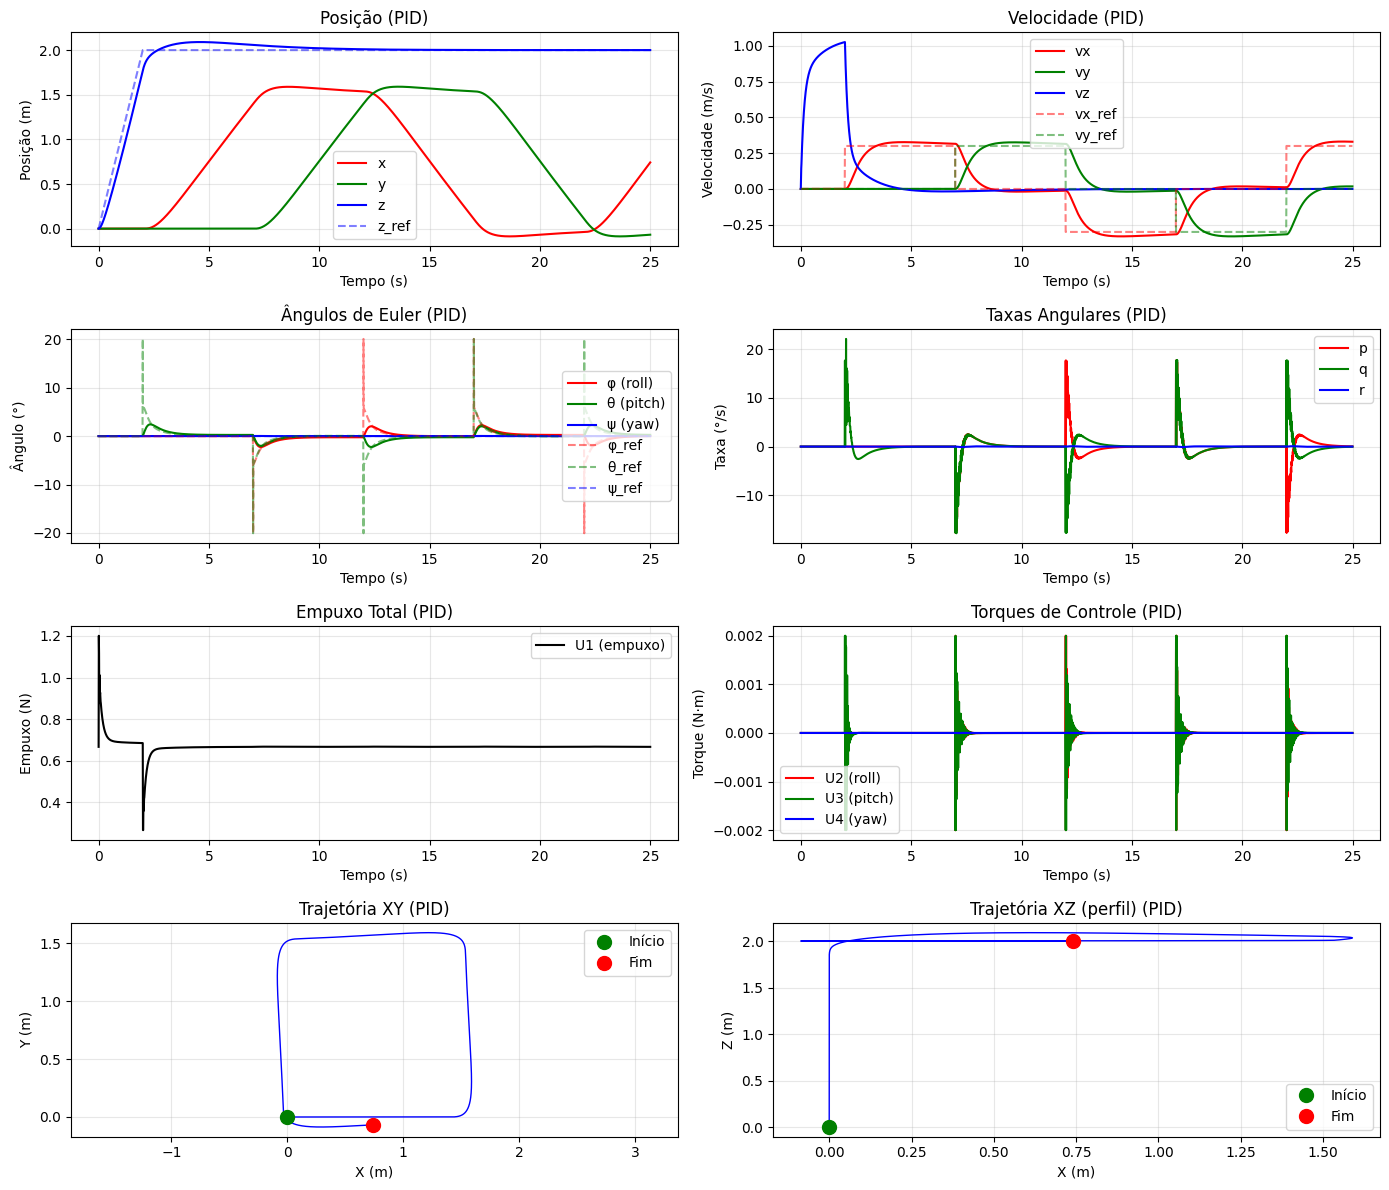

In [12]:
# Simulação com PID - trajetória quadrada para melhor visualização
print("=" * 50)
print("Simulação com Controlador PID de Atitude")
print("=" * 50)

sim_pid = QuadcopterSimulator(params, dt=0.01, attitude_controller='PID')
history_pid = sim_pid.simulate(duration=25.0, trajectory_func=trajectory_square)

print(f"Simulação concluída: {len(history_pid['time'])} passos")
print(f"Posição final: x={history_pid['state'][-1, 0]:.2f}, y={history_pid['state'][-1, 1]:.2f}, z={history_pid['state'][-1, 2]:.2f}")

# Plota resultados
plot_simulation_results(history_pid, "(PID)")

## 8.2 Simulação com Controle LQR Discreto

Simulação com Controlador LQR Discreto de Atitude
Criando controlador LQR para ESP32 drone...
Ganho LQR calculado (ESP32 drone):
[[0.00773943 0.         0.         0.00268398 0.         0.        ]
 [0.         0.00773943 0.         0.         0.00268398 0.        ]
 [0.         0.         0.0063491  0.         0.         0.00238884]]


Simulação concluída: 2500 passos
Posição final: x=0.76, y=-0.05, z=2.00


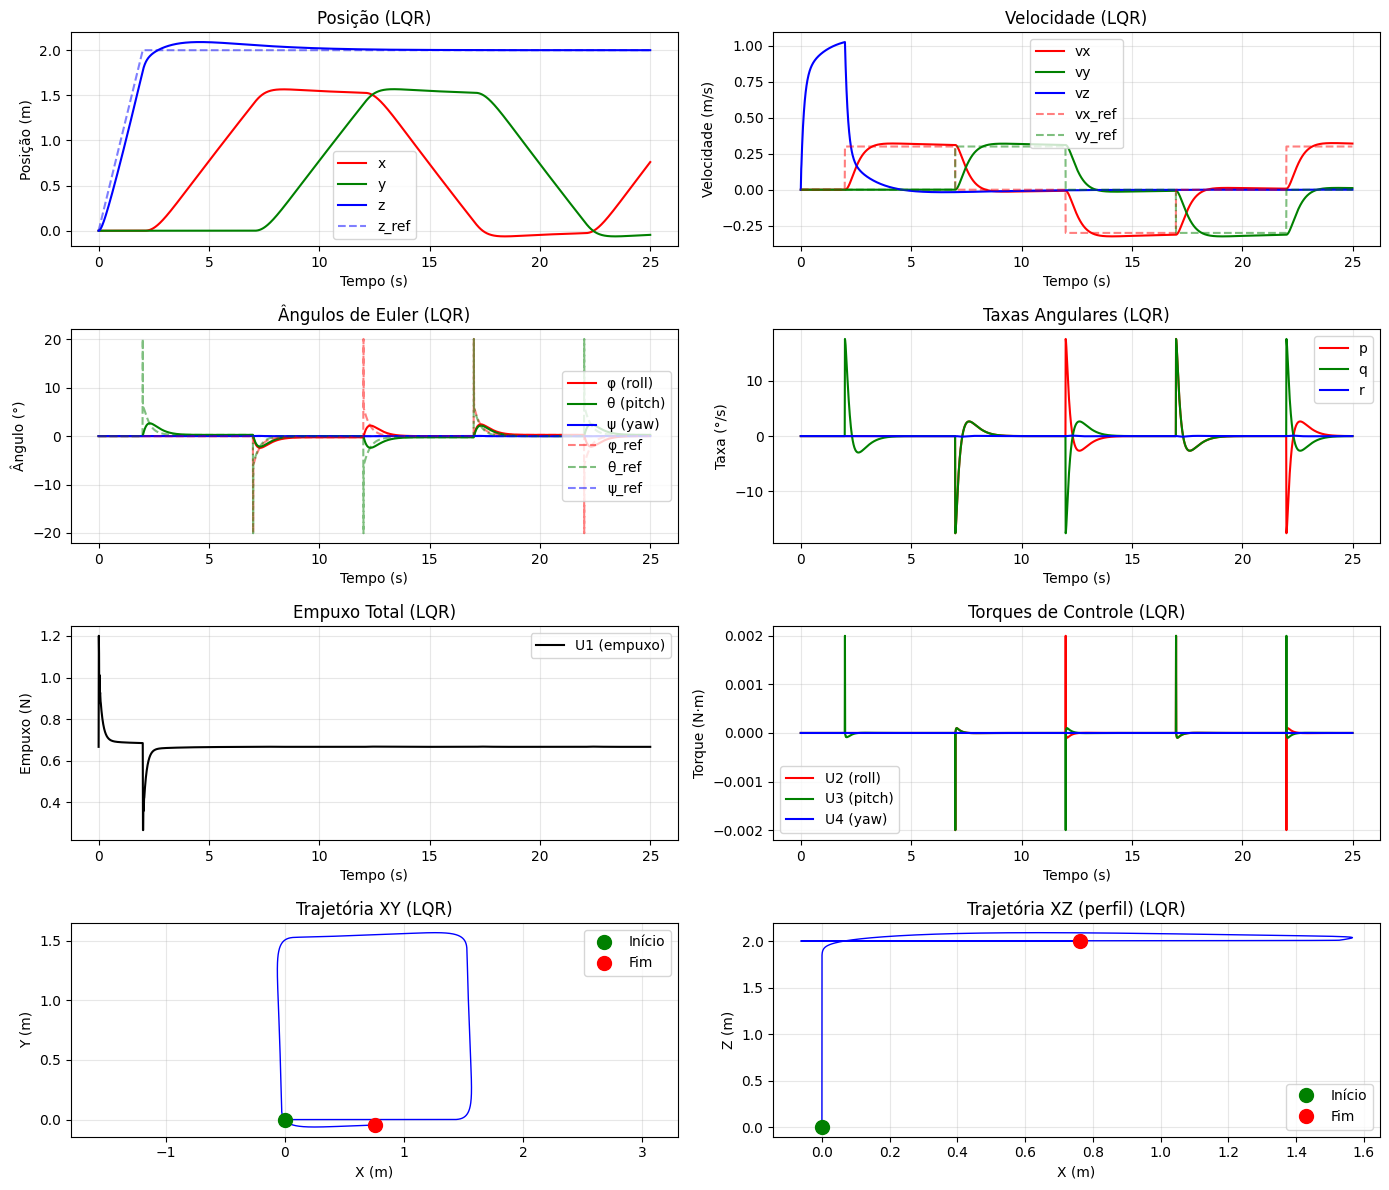

In [13]:
# Simulação com LQR
print("=" * 50)
print("Simulação com Controlador LQR Discreto de Atitude")
print("=" * 50)

sim_lqr = QuadcopterSimulator(params, dt=0.01, attitude_controller='LQR')
history_lqr = sim_lqr.simulate(duration=25.0, trajectory_func=trajectory_square)

print(f"Simulação concluída: {len(history_lqr['time'])} passos")
print(f"Posição final: x={history_lqr['state'][-1, 0]:.2f}, y={history_lqr['state'][-1, 1]:.2f}, z={history_lqr['state'][-1, 2]:.2f}")

# Plota resultados
plot_simulation_results(history_lqr, "(LQR)")

## 8.3 Simulação com Controle SDRE Discreto (Não-Linear)

Simulação com Controlador SDRE Discreto de Atitude


Simulação concluída: 2500 passos
Posição final: x=0.76, y=-0.05, z=2.00


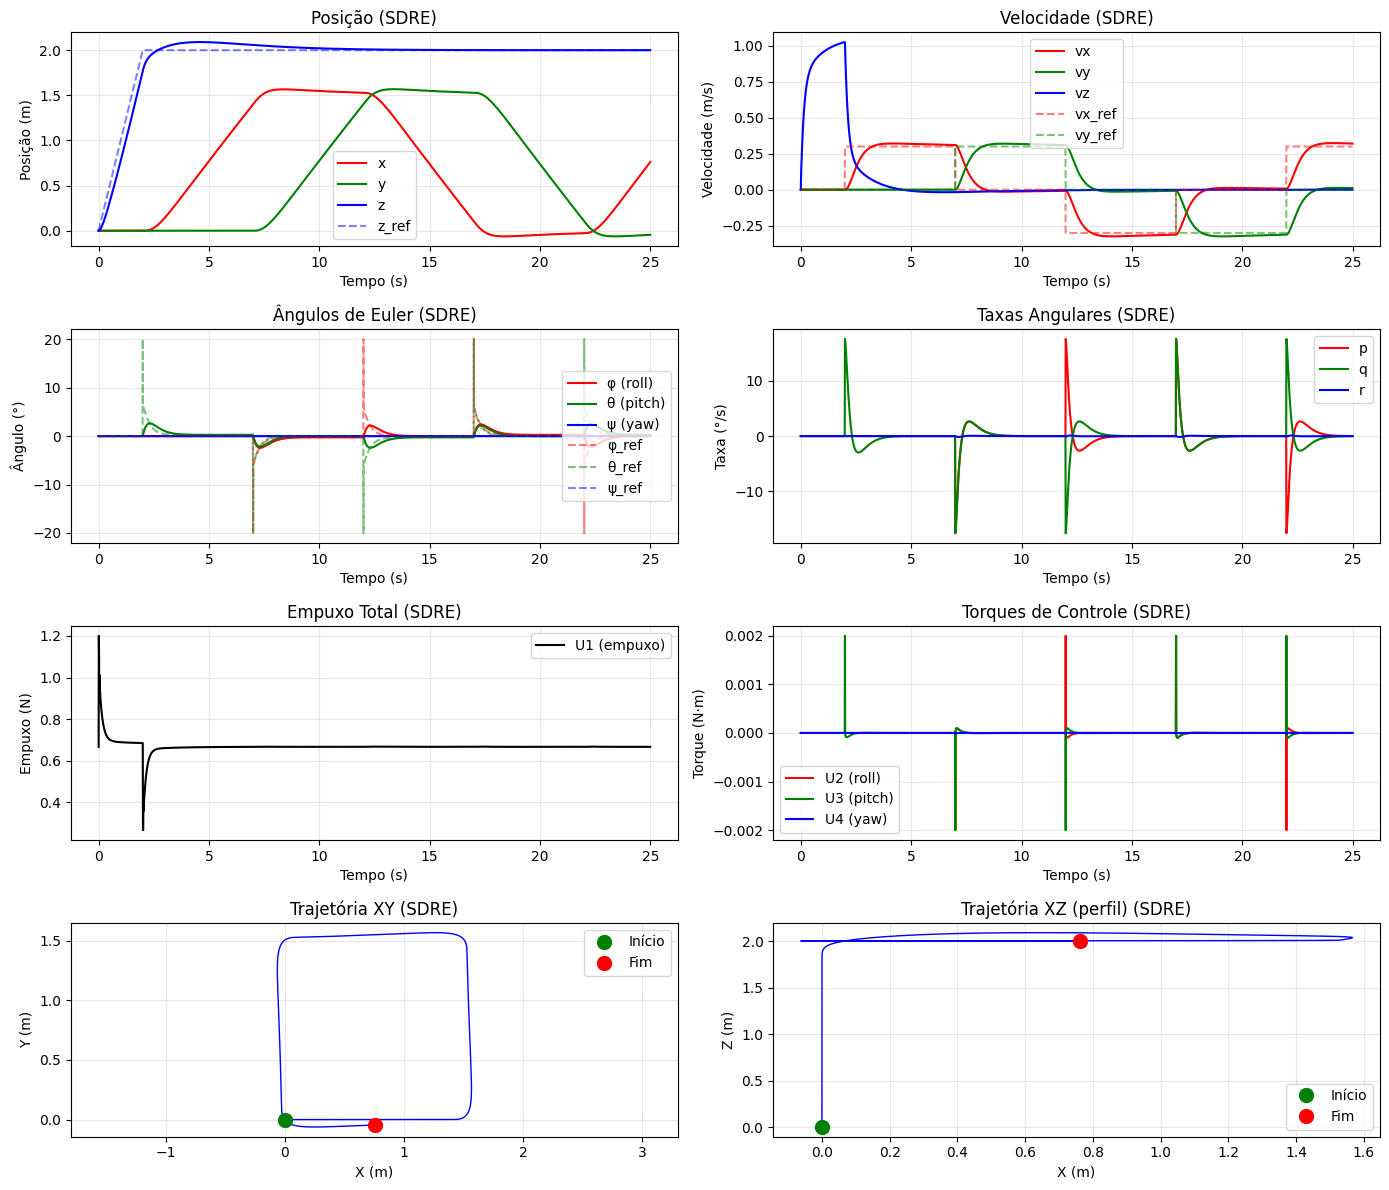

In [14]:
# Simulação com SDRE
print("=" * 50)
print("Simulação com Controlador SDRE Discreto de Atitude")
print("=" * 50)

sim_sdre = QuadcopterSimulator(params, dt=0.01, attitude_controller='SDRE')
history_sdre = sim_sdre.simulate(duration=25.0, trajectory_func=trajectory_square)

print(f"Simulação concluída: {len(history_sdre['time'])} passos")
print(f"Posição final: x={history_sdre['state'][-1, 0]:.2f}, y={history_sdre['state'][-1, 1]:.2f}, z={history_sdre['state'][-1, 2]:.2f}")

# Plota resultados
plot_simulation_results(history_sdre, "(SDRE)")

## 8.4 Comparação entre Controladores

Comparação dos controladores de atitude


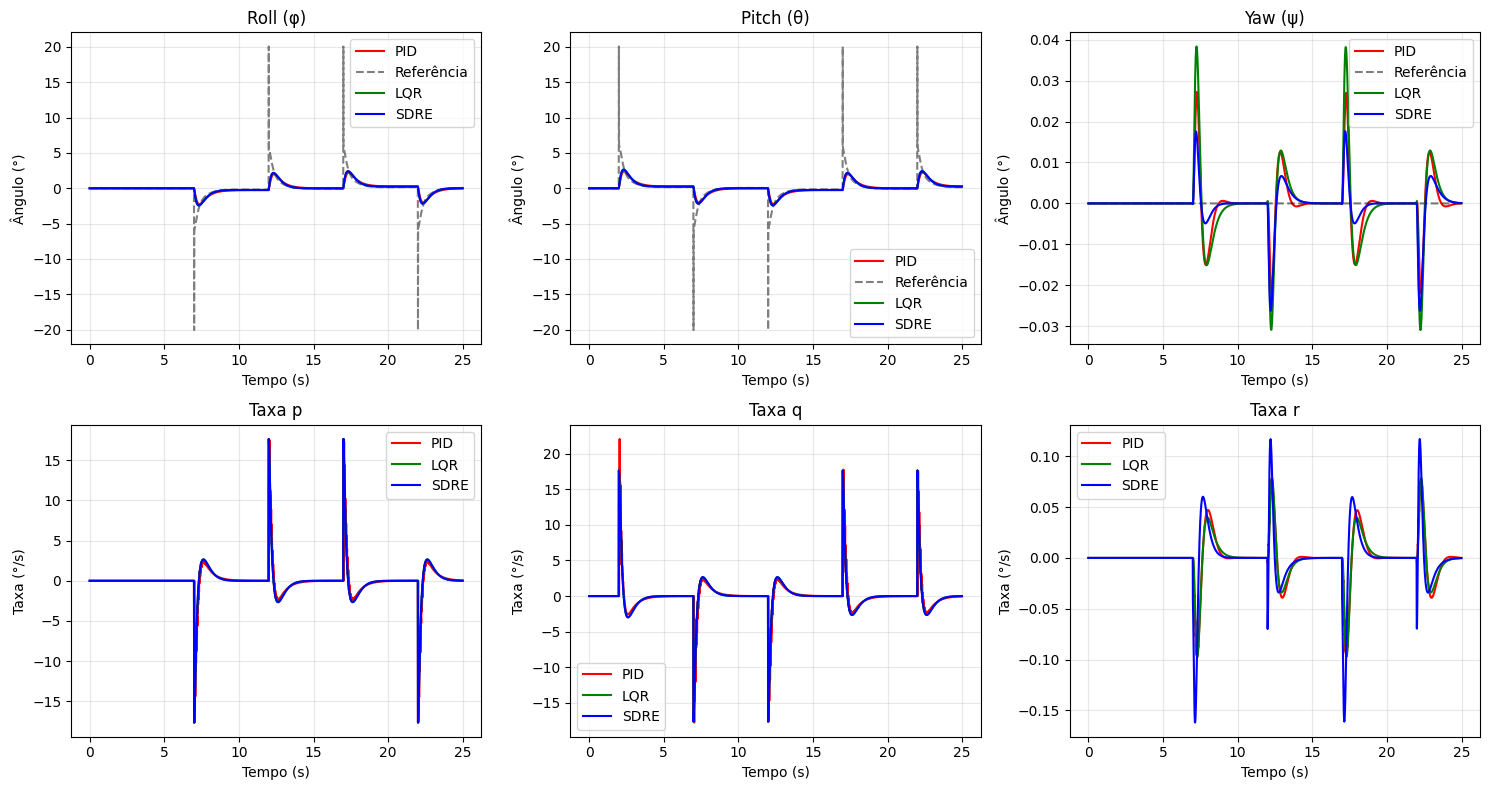

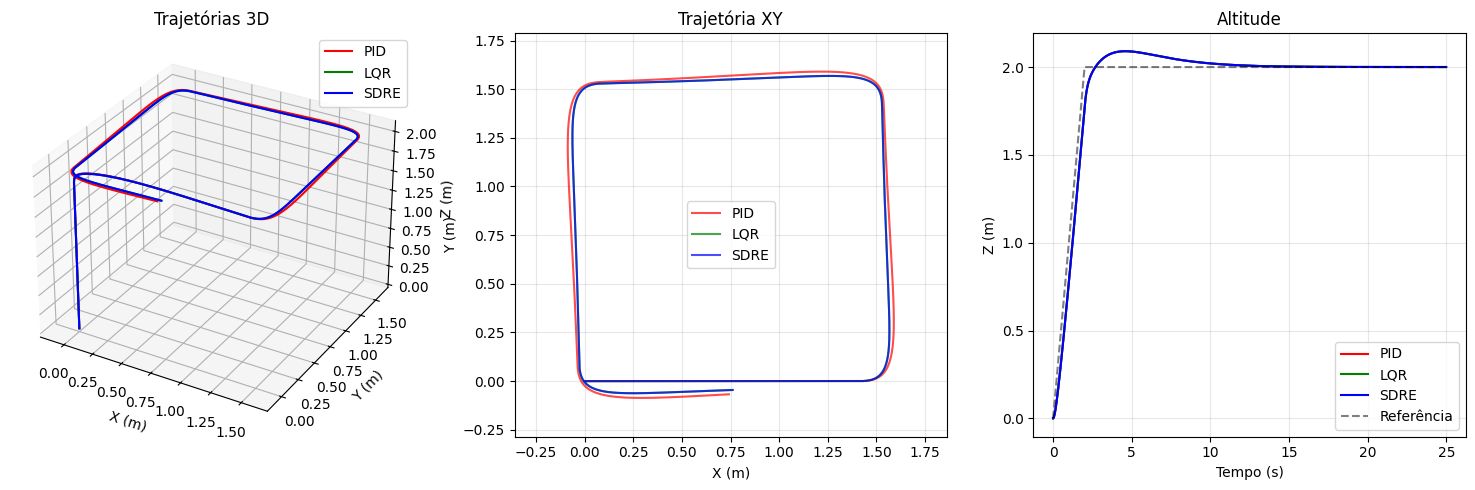

In [15]:
# Comparação dos ângulos entre os três controladores
print("Comparação dos controladores de atitude")
plot_angle_comparison(
    [history_pid, history_lqr, history_sdre],
    ['PID', 'LQR', 'SDRE']
)

# Comparação das trajetórias
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(history_pid['state'][:, 0], history_pid['state'][:, 1], history_pid['state'][:, 2], 'r-', label='PID')
ax1.plot(history_lqr['state'][:, 0], history_lqr['state'][:, 1], history_lqr['state'][:, 2], 'g-', label='LQR')
ax1.plot(history_sdre['state'][:, 0], history_sdre['state'][:, 1], history_sdre['state'][:, 2], 'b-', label='SDRE')
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('Trajetórias 3D')
ax1.legend()

ax2 = fig.add_subplot(132)
ax2.plot(history_pid['state'][:, 0], history_pid['state'][:, 1], 'r-', label='PID', alpha=0.7)
ax2.plot(history_lqr['state'][:, 0], history_lqr['state'][:, 1], 'g-', label='LQR', alpha=0.7)
ax2.plot(history_sdre['state'][:, 0], history_sdre['state'][:, 1], 'b-', label='SDRE', alpha=0.7)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Trajetória XY')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

ax3 = fig.add_subplot(133)
ax3.plot(history_pid['time'], history_pid['state'][:, 2], 'r-', label='PID')
ax3.plot(history_lqr['time'], history_lqr['state'][:, 2], 'g-', label='LQR')
ax3.plot(history_sdre['time'], history_sdre['state'][:, 2], 'b-', label='SDRE')
ax3.plot(history_pid['time'], history_pid['reference'][:, 0], 'k--', alpha=0.5, label='Referência')
ax3.set_xlabel('Tempo (s)')
ax3.set_ylabel('Z (m)')
ax3.set_title('Altitude')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Visualização 3D Animada

Animação do drone voando (similar ao Gazebo).

Gerando visualização 3D do drone com SDRE...


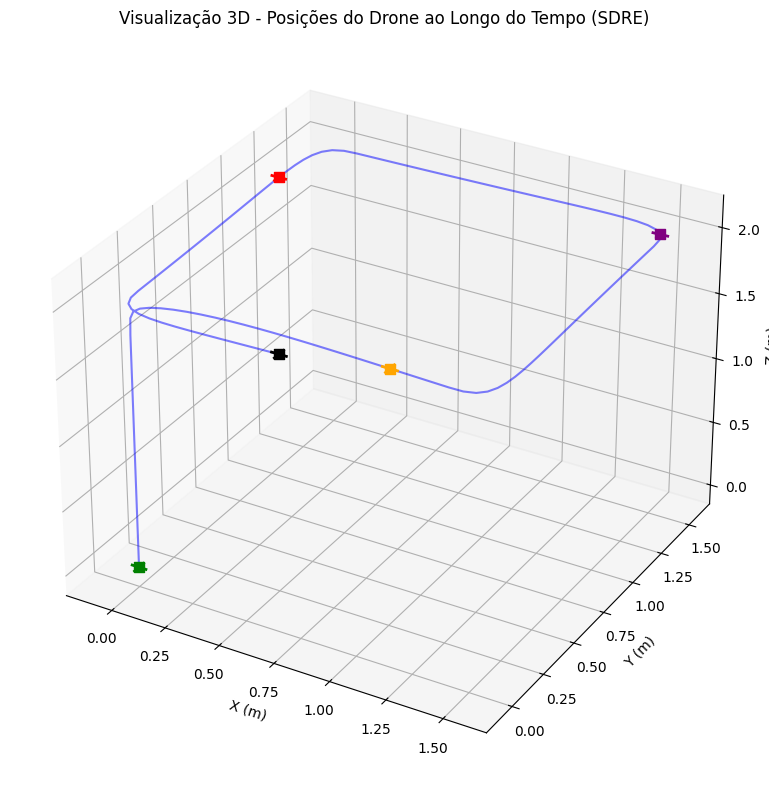


✓ Visualização 3D gerada!
  Os quadrados coloridos mostram a posição do drone em diferentes instantes:
  Verde=início, Laranja/Roxo/Vermelho=intermediários, Preto=final


In [16]:
# Visualização 3D do drone em múltiplos instantes de tempo
print("Gerando visualização 3D do drone com SDRE...")

# Usa menos dados para visualização mais rápida
skip = 20  # mostra 1 a cada 20 frames
states_viz = history_sdre['state'][::skip]
time_viz = history_sdre['time'][::skip]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plota trajetória completa
ax.plot(states_viz[:, 0], states_viz[:, 1], states_viz[:, 2], 'b-', alpha=0.5, label='Trajetória')

# Desenha drone em alguns pontos chave
visualizer = DroneVisualizer3D(params)
key_frames = [0, len(states_viz)//4, len(states_viz)//2, 3*len(states_viz)//4, -1]

colors = ['green', 'orange', 'purple', 'red', 'black']
for i, (idx, color) in enumerate(zip(key_frames, colors)):
    state = states_viz[idx]
    vertices = visualizer.get_drone_vertices(state)
    
    # Desenha braços
    for j in range(4):
        ax.plot([vertices[4, 0], vertices[j, 0]], 
                [vertices[4, 1], vertices[j, 1]], 
                [vertices[4, 2], vertices[j, 2]], 
                color=color, linewidth=2)
    
    ax.scatter(*vertices[4], s=50, c=color, marker='s')
    ax.text(vertices[4, 0], vertices[4, 1], vertices[4, 2] + 5, 
            f't={time_viz[idx]:.1f}s', fontsize=8, color=color)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Visualização 3D - Posições do Drone ao Longo do Tempo (SDRE)')

plt.tight_layout()
plt.show()

print("\n✓ Visualização 3D gerada!")
print("  Os quadrados coloridos mostram a posição do drone em diferentes instantes:")
print("  Verde=início, Laranja/Roxo/Vermelho=intermediários, Preto=final")

# 10. Métricas de Desempenho

Comparação quantitativa dos controladores.

In [17]:
def compute_metrics(history, controller_name):
    """Calcula métricas de desempenho do controlador"""
    states = history['state']
    controls = history['control']
    refs = history['reference']
    time = history['time']
    dt = time[1] - time[0]
    
    # Índice de tempo para ignorar transiente inicial (primeiros 3 segundos)
    start_idx = int(3.0 / dt)
    
    # Erros de rastreamento de ângulos
    angle_errors = np.abs(states[start_idx:, 6:9] - refs[start_idx:, 3:6])
    
    # RMSE dos ângulos (em graus)
    rmse_phi = np.sqrt(np.mean(angle_errors[:, 0]**2)) * 180/np.pi
    rmse_theta = np.sqrt(np.mean(angle_errors[:, 1]**2)) * 180/np.pi
    rmse_psi = np.sqrt(np.mean(angle_errors[:, 2]**2)) * 180/np.pi
    
    # Erro máximo de ângulos
    max_phi = np.max(np.abs(states[start_idx:, 6])) * 180/np.pi
    max_theta = np.max(np.abs(states[start_idx:, 7])) * 180/np.pi
    
    # Erro de altitude
    alt_error = np.abs(states[start_idx:, 2] - refs[start_idx:, 0])
    rmse_alt = np.sqrt(np.mean(alt_error**2))
    
    # Energia de controle (integral do quadrado dos torques)
    control_energy = np.sum(controls[start_idx:, 1:4]**2) * dt
    
    # Suavidade do controle (variação total)
    control_variation = np.sum(np.abs(np.diff(controls[start_idx:, 1:4], axis=0)))
    
    metrics = {
        'Controller': controller_name,
        'RMSE Roll (°)': rmse_phi,
        'RMSE Pitch (°)': rmse_theta,
        'RMSE Yaw (°)': rmse_psi,
        'Max Roll (°)': max_phi,
        'Max Pitch (°)': max_theta,
        'RMSE Alt (m)': rmse_alt,
        'Control Energy': control_energy,
        'Control Variation': control_variation
    }
    
    return metrics

# Calcula métricas para cada controlador
metrics_pid = compute_metrics(history_pid, 'PID')
metrics_lqr = compute_metrics(history_lqr, 'LQR')
metrics_sdre = compute_metrics(history_sdre, 'SDRE')

# Exibe tabela comparativa
print("\n" + "=" * 80)
print("COMPARAÇÃO DE DESEMPENHO DOS CONTROLADORES")
print("=" * 80)

headers = list(metrics_pid.keys())
print(f"\n{'Métrica':<20} {'PID':>15} {'LQR':>15} {'SDRE':>15}")
print("-" * 65)

for key in headers[1:]:  # Pula 'Controller'
    print(f"{key:<20} {metrics_pid[key]:>15.4f} {metrics_lqr[key]:>15.4f} {metrics_sdre[key]:>15.4f}")

print("\n" + "=" * 80)
print("Legenda:")
print("- RMSE: Root Mean Square Error (menor é melhor)")
print("- Control Energy: Energia total gasta em controle (menor é melhor)")
print("- Control Variation: Variação total do sinal de controle (menor = mais suave)")
print("=" * 80)


COMPARAÇÃO DE DESEMPENHO DOS CONTROLADORES

Métrica                          PID             LQR            SDRE
-----------------------------------------------------------------
RMSE Roll (°)                 1.1732          1.1180          1.1179
RMSE Pitch (°)                1.1736          1.1191          1.1192
RMSE Yaw (°)                  0.0064          0.0086          0.0050
Max Roll (°)                  2.2596          2.4245          2.4232
Max Pitch (°)                 2.2527          2.4173          2.4177
RMSE Alt (m)                  0.0361          0.0361          0.0361
Control Energy                0.0000          0.0000          0.0000
Control Variation             0.2843          0.0337          0.0338

Legenda:
- RMSE: Root Mean Square Error (menor é melhor)
- Control Energy: Energia total gasta em controle (menor é melhor)
- Control Variation: Variação total do sinal de controle (menor = mais suave)


# 11. Teste com Trajetória Agressiva

Teste de robustez dos controladores com manobras bruscas.

Teste com trajetória AGRESSIVA
Criando controlador LQR para ESP32 drone...
Ganho LQR calculado (ESP32 drone):
[[0.00773943 0.         0.         0.00268398 0.         0.        ]
 [0.         0.00773943 0.         0.         0.00268398 0.        ]
 [0.         0.         0.0063491  0.         0.         0.00238884]]


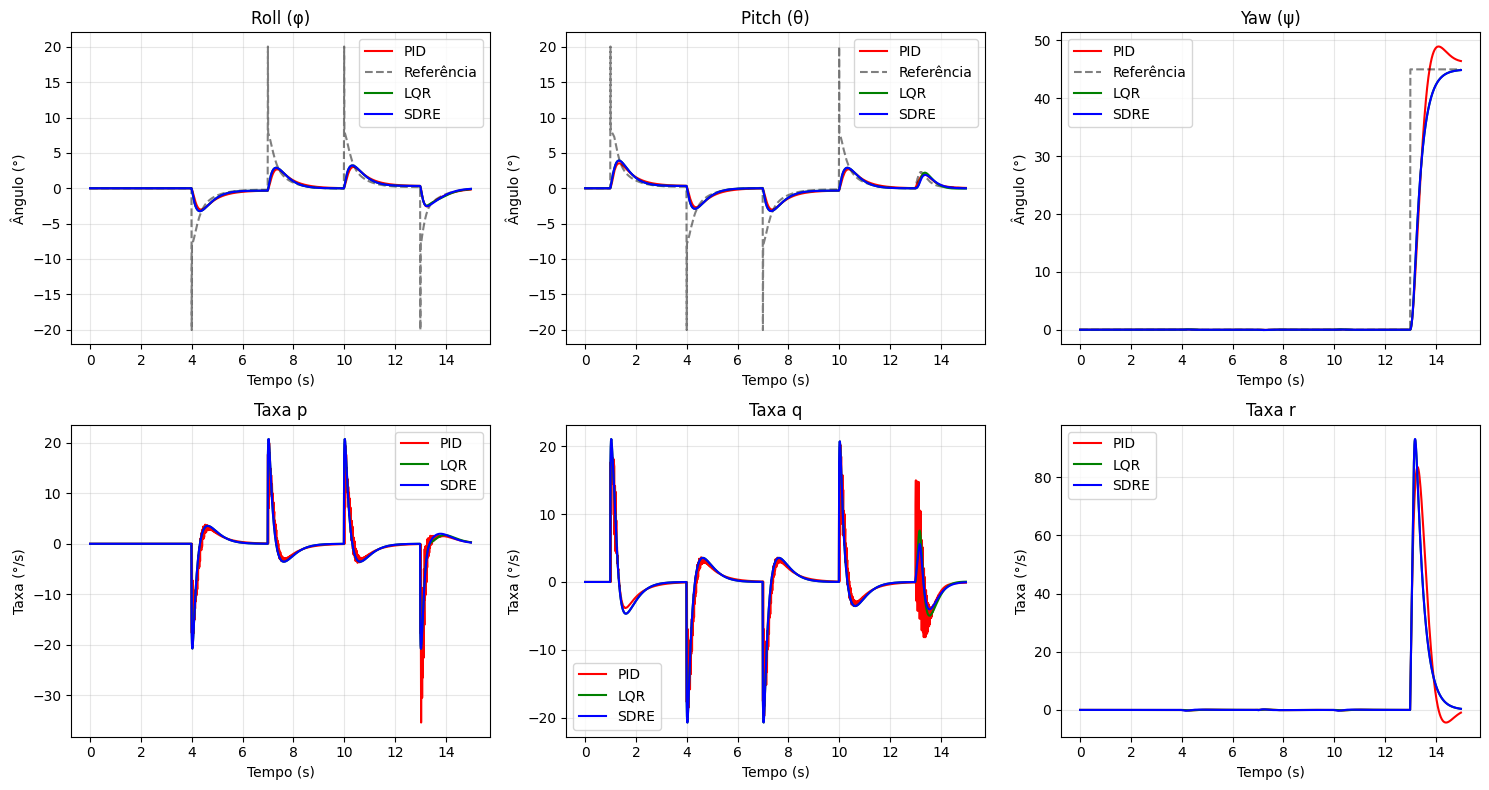


Métricas com trajetória agressiva:

Métrica                          PID             LQR            SDRE
-----------------------------------------------------------------
RMSE Roll (°)                 1.8830          1.7566          1.7596
RMSE Pitch (°)                1.6822          1.5943          1.5860
RMSE Yaw (°)                  6.7016          6.6044          6.6024
Max Roll (°)                  3.0206          3.2381          3.2347
Max Pitch (°)                 3.0174          3.2216          3.2226
RMSE Alt (m)                  0.0792          0.0792          0.0792
Control Energy                0.0000          0.0000          0.0000
Control Variation             0.4369          0.0334          0.0334


In [18]:
# Teste com trajetória agressiva
print("=" * 50)
print("Teste com trajetória AGRESSIVA")
print("=" * 50)

# Simula com cada controlador
sim_pid_agg = QuadcopterSimulator(params, dt=0.01, attitude_controller='PID')
sim_lqr_agg = QuadcopterSimulator(params, dt=0.01, attitude_controller='LQR')
sim_sdre_agg = QuadcopterSimulator(params, dt=0.01, attitude_controller='SDRE')

hist_pid_agg = sim_pid_agg.simulate(duration=15.0, trajectory_func=trajectory_aggressive)
hist_lqr_agg = sim_lqr_agg.simulate(duration=15.0, trajectory_func=trajectory_aggressive)
hist_sdre_agg = sim_sdre_agg.simulate(duration=15.0, trajectory_func=trajectory_aggressive)

# Compara os ângulos
plot_angle_comparison(
    [hist_pid_agg, hist_lqr_agg, hist_sdre_agg],
    ['PID', 'LQR', 'SDRE']
)

# Métricas
print("\nMétricas com trajetória agressiva:")
m_pid = compute_metrics(hist_pid_agg, 'PID')
m_lqr = compute_metrics(hist_lqr_agg, 'LQR')
m_sdre = compute_metrics(hist_sdre_agg, 'SDRE')

print(f"\n{'Métrica':<20} {'PID':>15} {'LQR':>15} {'SDRE':>15}")
print("-" * 65)
for key in list(m_pid.keys())[1:]:
    print(f"{key:<20} {m_pid[key]:>15.4f} {m_lqr[key]:>15.4f} {m_sdre[key]:>15.4f}")

# 12. Simulação Interativa

Função para rodar simulações customizadas facilmente.

In [19]:
def run_simulation(controller_type='SDRE', trajectory='circle', duration=20.0, 
                   show_animation=True, show_plots=True):
    """
    Função para rodar simulações de forma fácil
    
    Args:
        controller_type: 'PID', 'LQR' ou 'SDRE'
        trajectory: 'hover', 'square', 'circle', 'figure8', 'aggressive'
        duration: tempo de simulação em segundos
        show_animation: se True, mostra animação 3D
        show_plots: se True, mostra gráficos
        
    Returns:
        history: histórico da simulação
    """
    # Seleciona trajetória
    trajectories = {
        'hover': trajectory_takeoff_hover,
        'square': trajectory_square,
        'circle': trajectory_circle,
        'figure8': trajectory_figure8,
        'aggressive': trajectory_aggressive
    }
    
    if trajectory not in trajectories:
        raise ValueError(f"Trajetória '{trajectory}' não encontrada. Use: {list(trajectories.keys())}")
    
    traj_func = trajectories[trajectory]
    
    # Cria e roda simulador
    print(f"\n{'='*60}")
    print(f"Simulação: {controller_type} - Trajetória: {trajectory}")
    print(f"Duração: {duration}s")
    print(f"{'='*60}")
    
    sim = QuadcopterSimulator(params, dt=0.01, attitude_controller=controller_type)
    history = sim.simulate(duration=duration, trajectory_func=traj_func)
    
    print(f"✓ Simulação concluída!")
    print(f"  Posição final: ({history['state'][-1, 0]:.2f}, {history['state'][-1, 1]:.2f}, {history['state'][-1, 2]:.2f})")
    
    if show_plots:
        plot_simulation_results(history, f"({controller_type} - {trajectory})")
    
    if show_animation:
        print("\nGerando animação 3D...")
        viz = DroneVisualizer3D(params)
        anim = viz.create_animation(history, skip_frames=3)
        return history, HTML(anim.to_jshtml())
    
    return history

# Exemplo de uso
print("Função run_simulation criada!")
print("\nExemplo de uso:")
print("  history = run_simulation(controller_type='SDRE', trajectory='circle', duration=15.0)")
print("\nTrajetórias disponíveis: 'hover', 'square', 'circle', 'figure8', 'aggressive'")
print("Controladores: 'PID', 'LQR', 'SDRE'")

Função run_simulation criada!

Exemplo de uso:
  history = run_simulation(controller_type='SDRE', trajectory='circle', duration=15.0)

Trajetórias disponíveis: 'hover', 'square', 'circle', 'figure8', 'aggressive'
Controladores: 'PID', 'LQR', 'SDRE'


# 13. Exemplo: Simulação com Figura 8


Simulação: SDRE - Trajetória: figure8
Duração: 20.0s


✓ Simulação concluída!
  Posição final: (0.37, -0.33, 2.00)


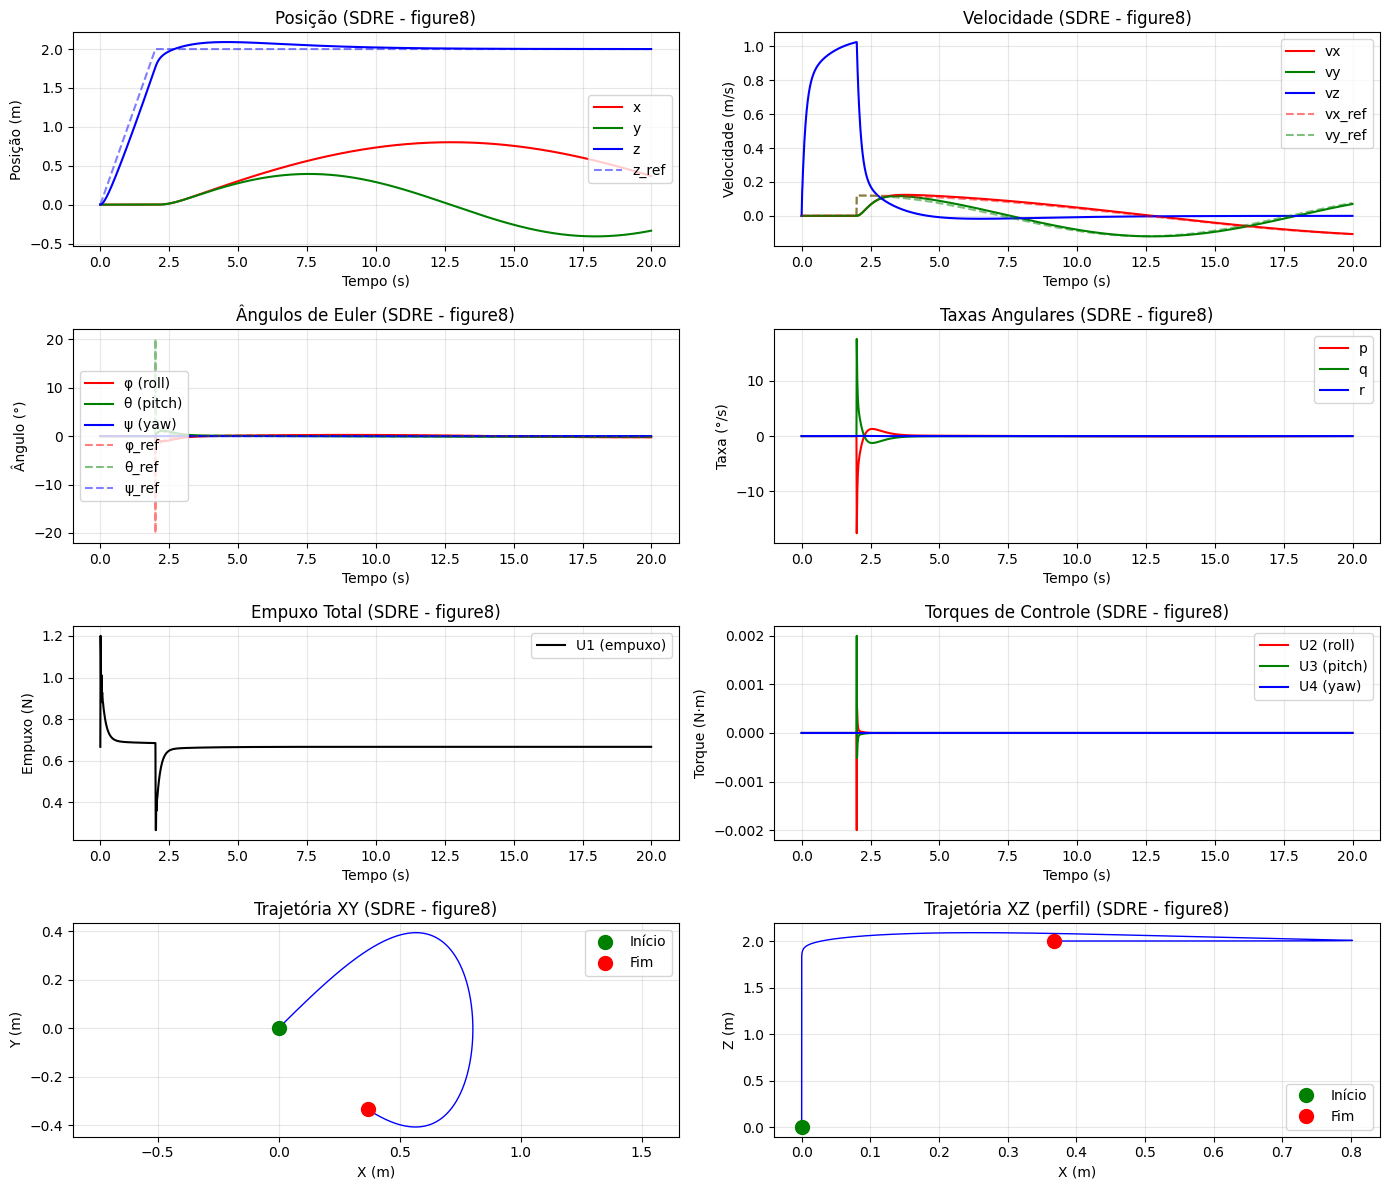

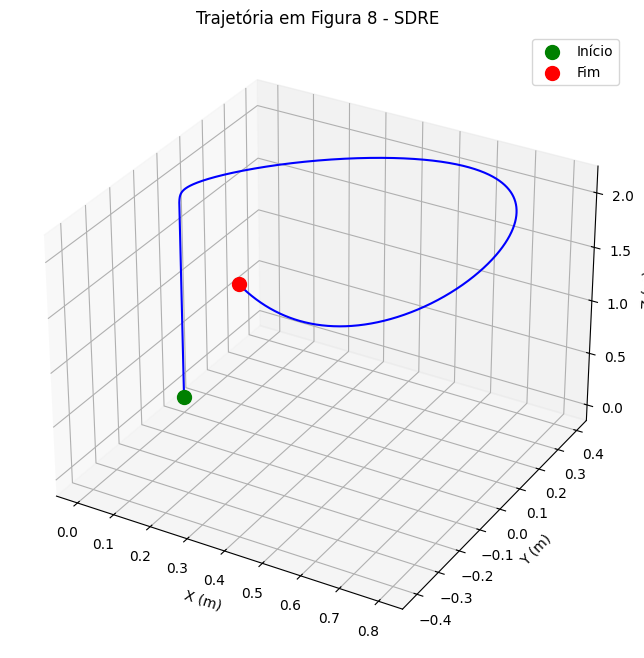

In [20]:
# Exemplo: Simulação com trajetória em forma de 8 (lemniscata) usando SDRE
hist_fig8 = run_simulation(
    controller_type='SDRE',
    trajectory='figure8',
    duration=20.0,
    show_animation=False,  # Desativa animação pesada
    show_plots=True
)

# Visualização 3D estática
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(hist_fig8['state'][:, 0], hist_fig8['state'][:, 1], hist_fig8['state'][:, 2], 'b-')
ax.scatter(hist_fig8['state'][0, 0], hist_fig8['state'][0, 1], hist_fig8['state'][0, 2], 
           s=100, c='green', marker='o', label='Início')
ax.scatter(hist_fig8['state'][-1, 0], hist_fig8['state'][-1, 1], hist_fig8['state'][-1, 2], 
           s=100, c='red', marker='o', label='Fim')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Trajetória em Figura 8 - SDRE')
ax.legend()
plt.show()

# 14. Resumo do Simulador

## Estrutura do Simulador

O simulador implementa:

### Dinâmica
- **Modelo não-linear completo** de um quadricóptero com 12 estados
- Equações de Newton-Euler para translação e rotação
- Efeitos de acoplamento giroscópico
- Arrasto aerodinâmico

### Controladores de Atitude (ângulos φ, θ, ψ)
1. **PID**: Controle clássico em cascata (ângulo → taxa → torque)
2. **LQR Discreto**: Controle linear com ganho calculado via DARE
3. **SDRE Discreto**: Controle não-linear com matrizes SDC (State-Dependent Coefficient)

### Controladores Auxiliares (sempre PID)
- **Altitude (Z)**: PID para manter/alcançar altitude desejada
- **Velocidade (XY)**: PID que converte velocidades desejadas em ângulos de referência

### Visualização
- Animação 3D em tempo real similar ao Gazebo
- Gráficos de todos os estados e sinais de controle
- Comparação entre controladores

## Como Usar

```python
# Simulação simples
history = run_simulation(
    controller_type='SDRE',  # 'PID', 'LQR' ou 'SDRE'
    trajectory='circle',     # 'hover', 'square', 'circle', 'figure8', 'aggressive'
    duration=20.0,
    show_animation=True
)
```